Cargamos las librerías a usar.

In [55]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

Cargamos los archivos csv y los volvemos dataframes.

In [56]:
servicio_de_restaurantes = pd.read_csv('/Users/mr04/Desktop/FINAL PROJECT/datos/servicio de restaurantes.csv')
servicio_hospedaje = pd.read_csv('/Users/mr04/Desktop/FINAL PROJECT/datos/servicio_hospedaje.csv')
servicio_transporte = pd.read_csv('/Users/mr04/Desktop/FINAL PROJECT/datos/servicio_trasporte.csv')
servicio_ventas = pd.read_csv('/Users/mr04/Desktop/FINAL PROJECT/datos/servicio_ventas.csv')
servicios_entretenimiento = pd.read_csv('/Users/mr04/Desktop/FINAL PROJECT/datos/servicios entretenimiento.csv')
servicios_educacion = pd.read_csv('/Users/mr04/Desktop/FINAL PROJECT/datos/servicios_educacion.csv')


/var/folders/p6/23qwfqrx3qn8083mwkrrppmr0000gn/T/ipykernel_1035/3958158745.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  servicio_de_restaurantes = pd.read_csv('/Users/mr04/Desktop/FINAL PROJECT/datos/servicio de restaurantes.csv')
/var/folders/p6/23qwfqrx3qn8083mwkrrppmr0000gn/T/ipykernel_1035/3958158745.py:6: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  servicios_educacion = pd.read_csv('/Users/mr04/Desktop/FINAL PROJECT/datos/servicios_educacion.csv')


A continuación se tratara cada uno de los archivos para poder juntarlos en un solo dataframe. 

In [57]:
servicio_de_restaurantes.head() #revisamos que datos tenemos 

,id_nombre,nombre,direccion,id_condado,condado,codigo_postal_condado,latitud_condado,longitud_condado,id_ciudad,ciudad,...,longitud_ciudad,estado,atributos,categorias,puntuacion_usuarios,numero_de_reviews,analisis_sentimientos,url_del_negocio,enlaces_google_maps,anio
0,cfe9,Spain Restaurant & Toma Bar,513 N Tampa St,W0hC,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,RGTW,tampa,...,-82.458753,Florida,NaN,"Basque, Tapas Bars, Spanish, Restaurants",4.0,165.0,negativo,NaN,NaN,2010
1,fe6c,Players Sports Pub,4500 W Cypress St,W0hC,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,RGTW,tampa,...,-82.458753,Florida,NaN,"Food, Beer, Wine & Spirits, Sports Bars, Resta...",3.0,94.0,positivo,NaN,NaN,2010
2,ac10,Pita's Republic,805 E Bloomingdale Ave,2xjH,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,HGEX,valrico,...,-82.242032,Florida,NaN,"Mediterranean, Restaurants",4.5,14.0,positivo,NaN,NaN,2010
3,0b4c,Sonny's BBQ,724 Cypress Village Blvd.,TyeM,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,R17I,sun city center,...,-82.351759,Florida,NaN,"Caterers, American (New), Restaurants, Barbequ...",3.0,56.0,negativo,NaN,NaN,2010
4,0b4c,Sonny's BBQ,724 Cypress Village Blvd.,TyeM,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,R17I,sun city center,...,-82.351759,Florida,NaN,"Caterers, American (New), Restaurants, Barbequ...",3.0,56.0,negativo,NaN,NaN,2010


Buscamos duplicados teniendo como filtro que no tengan ni el nombre ni la dirección repetidas. Con esto se busca que al buscar duplicados, si un restaurante tiene mas de una sede, no sea eliminado. 

In [58]:
servicio_de_restaurantes= servicio_de_restaurantes.drop_duplicates(subset=['nombre','direccion'], keep='first') 

Borramos las columnas que no usaremos en nuestro análisis

In [59]:
servicio_de_restaurantes= servicio_de_restaurantes.drop(['id_nombre',
                                                         'direccion',
                                                         'id_condado', 
                                                         'codigo_postal_condado',
                                                         'latitud_condado',
                                                         'longitud_condado',
                                                         'id_ciudad',
                                                         'codigo_postal_ciudad',
                                                         'latitud_ciudad',
                                                         'longitud_ciudad',
                                                         'atributos',
                                                         'analisis_sentimientos',
                                                         'url_del_negocio',
                                                         'enlaces_google_maps'], axis=1, inplace=False)

Revisamos que los cambios se hayan aplicado.

In [60]:
servicio_de_restaurantes.head(2)

,nombre,condado,ciudad,estado,categorias,puntuacion_usuarios,numero_de_reviews,anio
0,Spain Restaurant & Toma Bar,Hillsborough,tampa,Florida,"Basque, Tapas Bars, Spanish, Restaurants",4.0,165.0,2010
1,Players Sports Pub,Hillsborough,tampa,Florida,"Food, Beer, Wine & Spirits, Sports Bars, Resta...",3.0,94.0,2010


Se hará el mismo proceso con los siguiente dataframes: <br>
    - servicio_hospedaje, <br>
    - servicio_transporte,<br>
    - servicio_ventas,<br>
    - servicios_entretenimiento,<br>
    - servicios_educacion

In [61]:
servicio_hospedaje.head(2) 

,id_nombre,nombre,direccion,id_condado,condado,codigo_postal_condado,latitud_condado,longitud_condado,id_ciudad,ciudad,...,longitud_ciudad,estado,atributos,categorias,puntuacion_usuarios,numero_de_reviews,analisis_sentimientos,url_del_negocio,enlaces_google_maps,anio
0,207a,Splitsville,"615 Channelside Dr, Ste 120",W0hC,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,RGTW,tampa,...,-82.458753,Florida,NaN,"Southern, Bars, Active Life, Restaurants, Nigh...",3.5,201.0,neutral,NaN,NaN,2010
1,387d,Bella's Italian Café,"1413 S Howard Ave, Ste 100",W0hC,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,RGTW,tampa,...,-82.458753,Florida,NaN,"Restaurants, Italian",4.0,570.0,positivo,NaN,NaN,2010


In [62]:
servicio_hospedaje= servicio_hospedaje.drop_duplicates(subset=['nombre','direccion'], keep='first')

In [63]:
servicio_hospedaje= servicio_hospedaje.drop(['id_nombre',
                                                         'direccion',
                                                         'id_condado', 
                                                         'codigo_postal_condado',
                                                         'latitud_condado',
                                                         'longitud_condado',
                                                         'id_ciudad',
                                                         'codigo_postal_ciudad',
                                                         'latitud_ciudad',
                                                         'longitud_ciudad',
                                                         'atributos',
                                                         'analisis_sentimientos',
                                                         'url_del_negocio',
                                                         'enlaces_google_maps'], axis=1, inplace=False)

In [64]:
servicio_transporte.head(2)

,id_nombre,nombre,direccion,id_condado,condado,codigo_postal_condado,latitud_condado,longitud_condado,id_ciudad,ciudad,...,longitud_ciudad,estado,atributos,categorias,puntuacion_usuarios,numero_de_reviews,analisis_sentimientos,url_del_negocio,enlaces_google_maps,anio
0,e0df,Poppa's BBQ,12211 49th St N,UAIE,Pinellas,"33701, 33756, 33781",27.876394,-82.777858,MCCU,clearwater,...,-82.795895,Florida,NaN,"Restaurants, Barbeque",4.5,29.0,positivo,NaN,NaN,2010
1,a671,Fitzgerald's Irish Tavern,5811 Nebraska Ave,8iUB,Pasco,"34637, 34652, 34668",28.323242,-82.431940,3IHW,new port richey,...,-82.719267,Florida,NaN,"Cocktail Bars, Food, Beer, Wine & Spirits, Iri...",4.0,57.0,negativo,NaN,NaN,2010


In [65]:
servicio_transporte= servicio_transporte.drop_duplicates(subset=['nombre','direccion'], keep='first')

In [66]:
servicio_transporte= servicio_transporte.drop(['id_nombre',
                                                'direccion',
                                                'id_condado', 
                                                'codigo_postal_condado',
                                                'latitud_condado',
                                                'longitud_condado',
                                                'id_ciudad',
                                                'codigo_postal_ciudad',
                                                'latitud_ciudad',
                                                'longitud_ciudad',
                                                'atributos',
                                                'analisis_sentimientos',
                                                'url_del_negocio',
                                                'enlaces_google_maps'], axis=1, inplace=False)

In [67]:
servicios_entretenimiento.head(2)

,id_nombre,nombre,direccion,id_condado,condado,codigo_postal_condado,latitud_condado,longitud_condado,id_ciudad,ciudad,...,longitud_ciudad,estado,atributos,categorias,puntuacion_usuarios,numero_de_reviews,analisis_sentimientos,url_del_negocio,enlaces_google_maps,anio
0,edu722,Adventure Island,10001 N McKinley Dr,W0hC,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,RGTW,tampa,...,-82.458753,Florida,NaN,"Amusement Parks, Active Life, Water Parks",3.0,183.0,neutral,NaN,NaN,2010
1,656,AMC West Shore 14,210 Westshore Plaza,W0hC,Hillsborough,"33602, 33647, 33511",27.99036,-82.301773,RGTW,tampa,...,-82.458753,Florida,NaN,"Arts & Entertainment, Cinema",3.0,183.0,positivo,NaN,NaN,2010


In [68]:
servicios_entretenimiento= servicios_entretenimiento.drop_duplicates(subset=['nombre','direccion'], keep='first')

In [69]:
servicios_entretenimiento= servicios_entretenimiento.drop(['id_nombre',
                                                'direccion',
                                                'id_condado', 
                                                'codigo_postal_condado',
                                                'latitud_condado',
                                                'longitud_condado',
                                                'id_ciudad',
                                                'codigo_postal_ciudad',
                                                'latitud_ciudad',
                                                'longitud_ciudad',
                                                'atributos',
                                                'analisis_sentimientos',
                                                'url_del_negocio',
                                                'enlaces_google_maps'], axis=1, inplace=False)

In [70]:
servicio_ventas.head(2)

,id_nombre,nombre,direccion,id_condado,condado,codigo_postal_condado,latitud_condado,longitud_condado,id_ciudad,ciudad,...,longitud_ciudad,estado,atributos,categorias,puntuacion_usuarios,numero_de_reviews,analisis_sentimientos,url_del_negocio,enlaces_google_maps,anio
0,cf44,Peggy O'Neill's Irish Pub & Eatery,13910 W Hillsborough Ave,W0hC,Hillsborough,"33602, 33647, 33511",27.990360,-82.301773,RGTW,tampa,...,-82.458753,Florida,NaN,"Sports Bars, Karaoke, Nightlife, Irish, Bars, ...",3.5,49.0,positivo,NaN,NaN,2010
1,f401,Dome Grill Inc,561 Central Ave,L0b3,Pinellas,"33701, 33756, 33781",27.876394,-82.777858,p9Ny,st. petersburg,...,-82.638445,Florida,NaN,"Breakfast & Brunch, Diners, Greek, Restaurants",3.0,145.0,neutral,NaN,NaN,2010


In [71]:
servicio_ventas= servicio_ventas.drop_duplicates(subset=['nombre','direccion'], keep='first')

In [72]:
servicio_ventas= servicio_ventas.drop(['id_nombre',
                                                'direccion',
                                                'id_condado', 
                                                'codigo_postal_condado',
                                                'latitud_condado',
                                                'longitud_condado',
                                                'id_ciudad',
                                                'codigo_postal_ciudad',
                                                'latitud_ciudad',
                                                'longitud_ciudad',
                                                'atributos',
                                                'analisis_sentimientos',
                                                'url_del_negocio',
                                                'enlaces_google_maps'], axis=1, inplace=False)

In [73]:
servicios_educacion.head(2)

,id_nombre,nombre,direccion,id_condado,condado,codigo_postal_condado,latitud_condado,longitud_condado,id_ciudad,ciudad,...,longitud_ciudad,estado,atributos,categorias,puntuacion_usuarios,numero_de_reviews,analisis_sentimientos,url_del_negocio,enlaces_google_maps,anio
0,edu6505,YMCA of the Suncoast - Clearwater Branch,1005 S Highland Ave,UAIE,Pinellas,"33701, 33756, 33781",27.876394,-82.777858,MCCU,clearwater,...,-82.795895,Florida,NaN,"Swimming Lessons/Schools, Local Services, Kids...",3.5,21.0,negativo,NaN,NaN,2010
1,edu6387,USF Tampa Library,Null,W0hC,Hillsborough,"33602, 33647, 33511",27.990360,-82.301773,RGTW,tampa,...,-82.458753,Florida,NaN,"Education, Colleges & Universities",4.0,9.0,neutral,NaN,NaN,2010


In [74]:
servicios_educacion= servicios_educacion.drop_duplicates(subset=['nombre','direccion'], keep='first')

In [75]:
servicios_educacion= servicios_educacion.drop(['id_nombre',
                                                'direccion',
                                                'id_condado', 
                                                'codigo_postal_condado',
                                                'latitud_condado',
                                                'longitud_condado',
                                                'id_ciudad',
                                                'codigo_postal_ciudad',
                                                'latitud_ciudad',
                                                'longitud_ciudad',
                                                'atributos',
                                                'analisis_sentimientos',
                                                'url_del_negocio',
                                                'enlaces_google_maps'], axis=1, inplace=False)

Unimos todas las tablas para crear una sola en la cual haremos consultas y sacaremos nuestros gráficos. 

In [76]:
datos = pd.concat([
    servicio_de_restaurantes,
    servicio_hospedaje,
    servicio_transporte,
    servicio_ventas,
    servicios_entretenimiento,
    servicios_educacion], axis=0, ignore_index=True)

In [77]:
datos.duplicated() #revisamos nuevamente si hay duplicados. 

0        False
1        False
2        False
3        False
4        False
         ...  
59409    False
59410    False
59411    False
59412    False
59413    False
Length: 59414, dtype: bool

In [80]:
datos['puntuacion_usuarios'] = datos['puntuacion_usuarios'].fillna(0)
datos['numero_de_reviews'] = datos['numero_de_reviews'].fillna(0)
datos = datos[datos['ciudad'].str.match(r'^[a-zA-Z\s]+$', na=False)]

In [81]:
conteo_ciudades = datos['ciudad'].value_counts() #realizamos un conteo de ciudades para ver cuales tienen mas restaurantes en general. 

In [82]:
conteo_ciudades

ciudad
tampa               13055
clearwater           2968
hialeah              2787
saint petersburg     2722
brandon              2106
                    ...  
sorrento ave            1
square                  1
palmdale                1
s military trail        1
muay thai               1
Name: count, Length: 652, dtype: int64

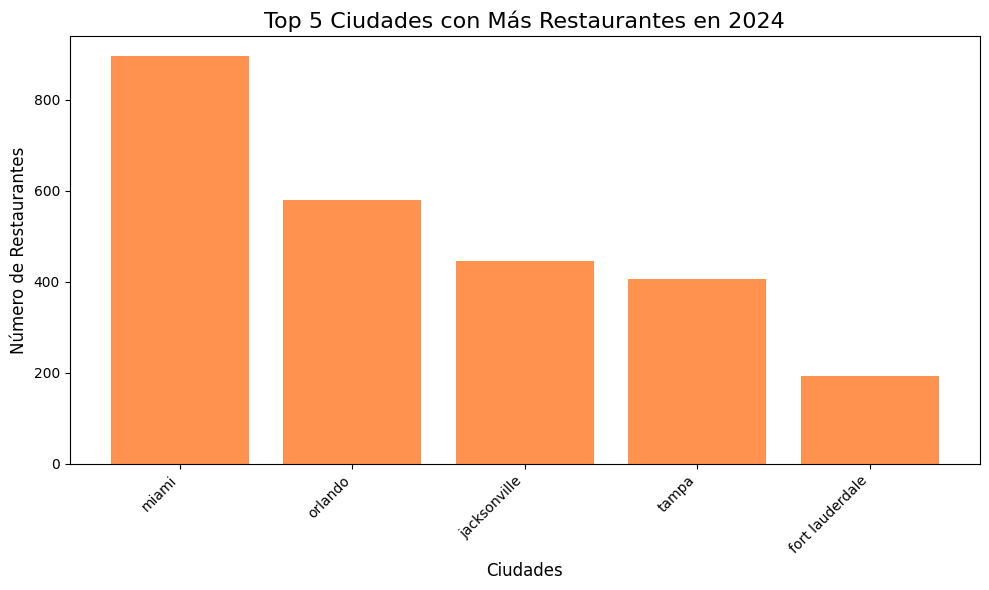

In [ ]:
# Se realiza un filtro para poder los restaurantes que hay abiertos en total por año. 
año_seleccionado = 2024
datos_filtrados_por_año = datos[datos['anio'] == año_seleccionado]

#agrupamos por ciudad y numero de rest. 
conteo_restaurantes_por_ciudad = datos_filtrados_por_año.groupby('ciudad')['nombre'].size().reset_index(name='num_restaurantes')

# filtramos el top 5 
top_5_ciudades = conteo_restaurantes_por_ciudad.nlargest(5, 'num_restaurantes')

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(top_5_ciudades['ciudad'], top_5_ciudades['num_restaurantes'], color='#FF924E')
# Títulos y etiquetas
plt.title(f'Top 5 Ciudades con Más Restaurantes en {año_seleccionado}', fontsize=16)
plt.xlabel('Ciudades', fontsize=12)
plt.ylabel('Número de Restaurantes', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()


In [84]:
print(top_5_ciudades) # vamos los valores detallados de cada gráfica. 

              ciudad  num_restaurantes
275            miami               896
333          orlando               580
203     jacksonville               445
456            tampa               407
144  fort lauderdale               193


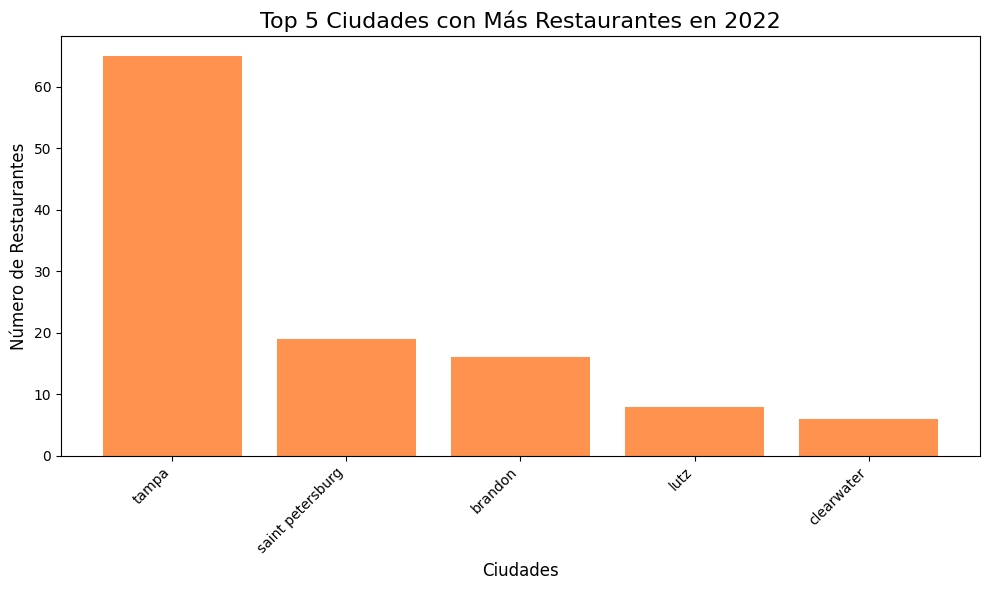

In [ ]:
# Se realiza un filtro para poder los restaurantes que hay abiertos en total por año. 
año_seleccionado = 2021
datos_filtrados_por_año = datos[datos['anio'] == año_seleccionado]

#agrupamos por ciudad y numero de rest. 
conteo_restaurantes_por_ciudad = datos_filtrados_por_año.groupby('ciudad')['nombre'].size().reset_index(name='num_restaurantes')

# filtramos el top 5 
top_5_ciudades = conteo_restaurantes_por_ciudad.nlargest(5, 'num_restaurantes')

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(top_5_ciudades['ciudad'], top_5_ciudades['num_restaurantes'], color='#FF924E')
# Títulos y etiquetas
plt.title(f'Top 5 Ciudades con Más Restaurantes en {año_seleccionado}', fontsize=16)
plt.xlabel('Ciudades', fontsize=12)
plt.ylabel('Número de Restaurantes', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()


In [86]:
print(top_5_ciudades)

              ciudad  num_restaurantes
17             tampa                65
15  saint petersburg                19
2            brandon                16
7               lutz                 8
3         clearwater                 6


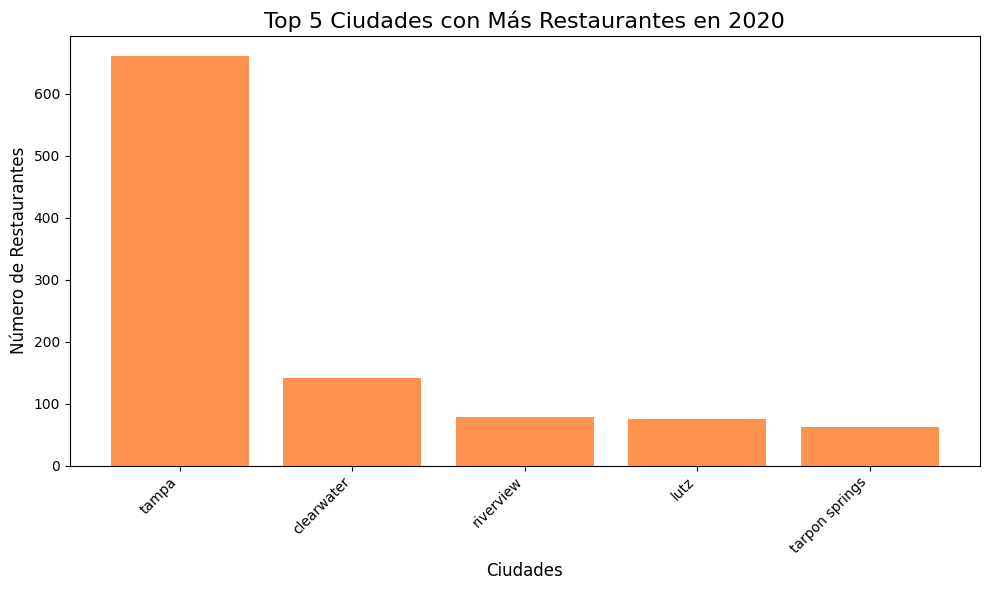

In [ ]:
# Se realiza un filtro para poder los restaurantes que hay abiertos en total por año. 
año_seleccionado = 2020
datos_filtrados_por_año = datos[datos['anio'] == año_seleccionado]

#agrupamos por ciudad y numero de rest. 
conteo_restaurantes_por_ciudad = datos_filtrados_por_año.groupby('ciudad')['nombre'].size().reset_index(name='num_restaurantes')

# filtramos el top 5 
top_5_ciudades = conteo_restaurantes_por_ciudad.nlargest(5, 'num_restaurantes')

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(top_5_ciudades['ciudad'], top_5_ciudades['num_restaurantes'], color='#FF924E')
# Títulos y etiquetas
plt.title(f'Top 5 Ciudades con Más Restaurantes en {año_seleccionado}', fontsize=16)
plt.xlabel('Ciudades', fontsize=12)
plt.ylabel('Número de Restaurantes', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()


In [88]:
print(top_5_ciudades)

            ciudad  num_restaurantes
37           tampa               660
2       clearwater               142
27       riverview                79
16            lutz                75
39  tarpon springs                62


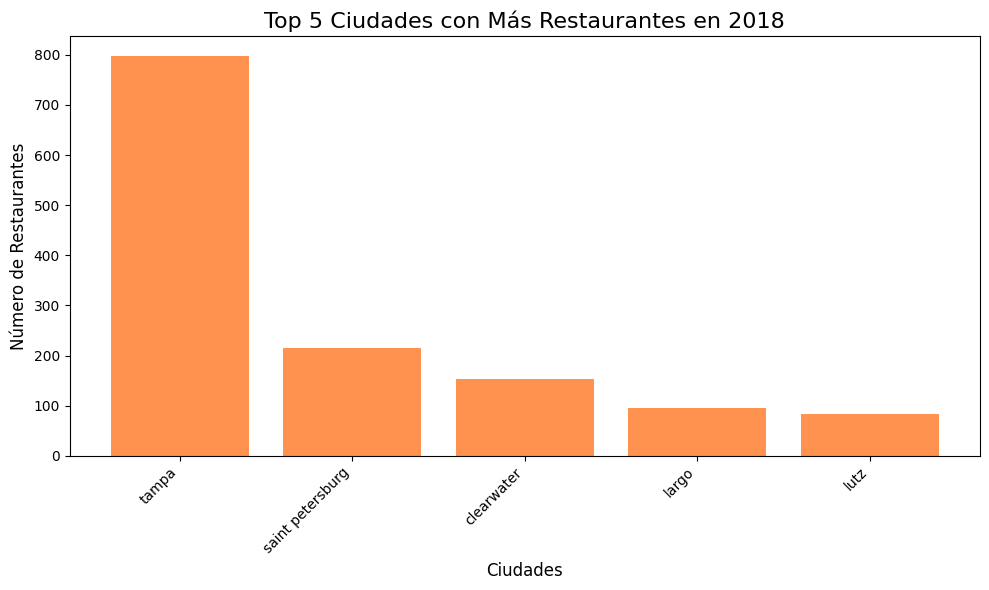

In [ ]:
# Se realiza un filtro para poder los restaurantes que hay abiertos en total por año. 
año_seleccionado = 2019
datos_filtrados_por_año = datos[datos['anio'] == año_seleccionado]

#agrupamos por ciudad y numero de rest. 
conteo_restaurantes_por_ciudad = datos_filtrados_por_año.groupby('ciudad')['nombre'].size().reset_index(name='num_restaurantes')

# filtramos el top 5 
top_5_ciudades = conteo_restaurantes_por_ciudad.nlargest(5, 'num_restaurantes')

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(top_5_ciudades['ciudad'], top_5_ciudades['num_restaurantes'], color='#FF924E')
# Títulos y etiquetas
plt.title(f'Top 5 Ciudades con Más Restaurantes en {año_seleccionado}', fontsize=16)
plt.xlabel('Ciudades', fontsize=12)
plt.ylabel('Número de Restaurantes', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()


In [90]:
print(top_5_ciudades)

              ciudad  num_restaurantes
46             tampa               798
40  saint petersburg               216
4         clearwater               154
21             largo                95
23              lutz                83


Revisamos que restaurantes tiene mas numeros de reviews para tomar una idea de que restaurantes son a los que mas les comentan.

In [ ]:
df_agrupado = datos.groupby('nombre')['numero_de_reviews'].sum().reset_index()
df_top_10 = df_agrupado.nlargest(10, 'numero_de_reviews')
print(df_top_10)

                         nombre  numero_de_reviews
4023                       Datz            13780.0
3492        Columbia Restaurant            13590.0
15666                     Ulele            12256.0
1644         Bern's Steak House            11696.0
5574   Frenchy's Rockaway Grill             9204.0
13963                  Taco Bus             8246.0
1955                     Bodega             7518.0
10609           Oxford Exchange             7472.0
3358             Clear Sky Cafe             7296.0
8638     Lolis Mexican Cravings             7296.0


In [96]:
datos.iloc[3492]

nombre                                               Mulligans Irish Pub
condado                                                     Hillsborough
ciudad                                                             tampa
estado                                                           Florida
categorias             Bars, Pubs, Irish Pub, Nightlife, Restaurants,...
puntuacion_usuarios                                                  4.0
numero_de_reviews                                                   42.0
anio                                                                2012
Name: 3796, dtype: object